In [6]:
import pandas as pd
import numpy as np

df_players = pd.read_csv("../data/raw/base_data/players.csv")
df_penalties = pd.read_csv("../data/processed/penalties_all.csv")


print(df_players)

       athleteId          firstName middleName         lastName  \
0           2821             Miguel        NaN          Ramírez   
1           2897            Alfredo        NaN         Amarilla   
2           2911              Mauro        NaN        Caballero   
3           3007               Noel        NaN       Valladares   
4           3038             Adrián        NaN         Martínez   
...          ...                ...        ...              ...   
69587    3095294               Álex        NaN  Beltrán Delgado   
69588    3095320              César        NaN     Díaz Camacho   
69589    3095420        Zion Angosé        NaN            Henry   
69590    3095774  Dieudonné Djoully        NaN            Nzoko   
69591    3095895              Pablo        NaN      Osán Ascaso   

                      fullName              displayName           shortName  \
0               Miguel Ramírez           Miguel Ramírez           M Ramírez   
1             Alfredo Amarilla       

/tmp/ipykernel_37258/1460305609.py:4: DtypeWarning: Columns (0: middleName, 1: birthPlaceCountry) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv("../data/raw/base_data/players.csv")


In [18]:
df_test = df_penalties.merge(df_players[['athleteId', 'dateOfBirth']], how='left', left_on='athleteId', right_on='athleteId')

In [19]:
df_test["dateOfBirth"] = (
    pd.to_datetime(df_test["dateOfBirth"], errors="coerce")
    .dt.year
    .astype("Int64")
)

In [21]:
df_test["age"] = df_test["year"] - df_test["dateOfBirth"]

In [22]:
df_test 

,seasonType,eventId,playOrder,playId,typeId,text,shortText,period,clockValue,clockDisplayValue,...,updateDateTime,year,competition,penalty_position,penalty_direction,save,goal,miss,dateOfBirth,age
0,12654,704285,28,43566230,98,"Goal! West Ham United 1, Aston Villa 1. Lucas ...",Lucas Paquetá Penalty - Scored,1,2216,37',...,2024-08-19 01:40:35,2024,ENG.1,9,bottom left,0,1,0,1997,27
1,12654,704295,8,43604996,98,"Goal! Manchester City 1, Ipswich Town 1. Erlin...",Erling Haaland Penalty - Scored,1,719,12',...,2024-10-14 03:04:32,2024,ENG.1,9,bottom left,0,1,0,2000,24
2,12654,704310,38,43744082,114,Penalty saved. Evanilson (Bournemouth) right f...,Evanilson Penalty - Saved,1,2271,38',...,2025-04-05 04:41:37,2024,ENG.1,7,bottom right,1,0,0,1999,25
3,12654,704312,76,43740821,98,"Goal! Crystal Palace 2, Leicester City 2. Jean...",Jean-Philippe Mateta Penalty - S,2,5400,90'+2',...,2024-09-28 01:47:40,2024,ENG.1,5,middle center,0,1,0,1997,27
4,12654,704316,18,43734585,114,Penalty saved. Cameron Archer (Southampton) ri...,Cameron Archer Penalty - Saved,1,1937,33',...,2024-09-16 01:26:05,2024,ENG.1,9,bottom left,1,0,0,2001,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,13688,757932,29,46866649,98,"Goal! Genk 1, Malmö 1. Daan Heymans (Genk) con...",Daan Heymans Penalty - Scored,1,2648,45',...,2026-02-05 06:03:21,2025,UEFA.EUROPA,7,bottom right,0,1,0,1999,26
1904,13688,757937,15,46865708,98,"Goal! Celtic 3, FC Utrecht 0. Arne Engels (Cel...",Arne Engels Penalty - Scored,1,1138,19',...,2026-01-30 05:56:29,2025,UEFA.EUROPA,1,top right,0,1,0,2003,22
1905,13684,401862907,26,47591282,114,Penalty saved. Rodrigo Zalazar (Sporting Braga...,Rodrigo Zalazar Penalty - Saved,1,2700,45'+2',...,2026-05-01 05:01:51,2025,UEFA.EUROPA,9,bottom left,1,0,0,1999,26
1906,13684,401862908,41,47591480,98,"Goal! Nottingham Forest 1, Aston Villa 0. Chri...",Chris Wood Penalty - Scored,2,4218,71',...,2026-05-01 05:01:51,2025,UEFA.EUROPA,3,top left,0,1,0,1991,34


In [40]:
df_test["age_group"] = pd.cut(
    df_test["age"],
    bins=[0, 17, 20, 22, 25, 28, 31, 34, float("inf")],
    labels=[
        "0-17",
        "18-20",
        "21-22",
        "23-25",
        "26-28",
        "29-31",
        "32-34",
        "35+"
    ]
)

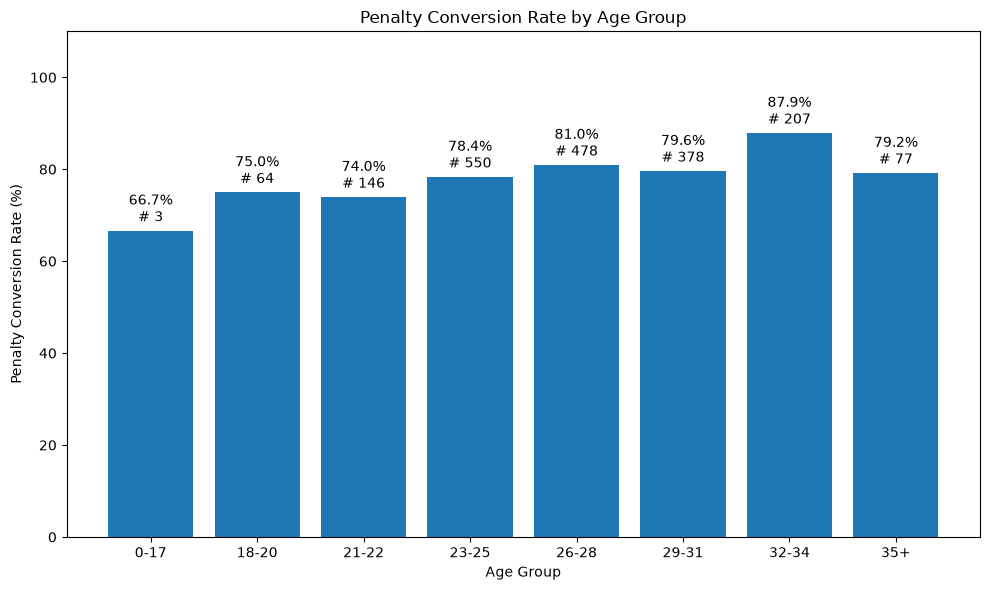

In [55]:
import matplotlib.pyplot as plt

stats_age = (
    df_test
    .groupby("age_group", observed=True)["goal"]
    .agg(
        percentage="mean",
        num_penalties="count"
    )
)

stats_age["percentage"] *= 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    stats_age.index.astype(str),
    stats_age["percentage"]
)

# Show percentage and number of penalties
for bar, percentage, n in zip(
    bars,
    stats_age["percentage"],
    stats_age["num_penalties"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.1f}%\n# {n}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xlabel("Age Group")
ax.set_ylabel("Penalty Conversion Rate (%)")
ax.set_title("Penalty Conversion Rate by Age Group")

ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

In [45]:
import re
import pandas as pd

# Extract 'left' or 'right' when followed by optional spaces/hyphens and 'footed'
df_penalties["foot"] = df_penalties["text"].str.extract(
    r"\b(left|right)[-\s]+footed\b", flags=re.IGNORECASE
)


<Axes: xlabel='foot,penalty_direction'>

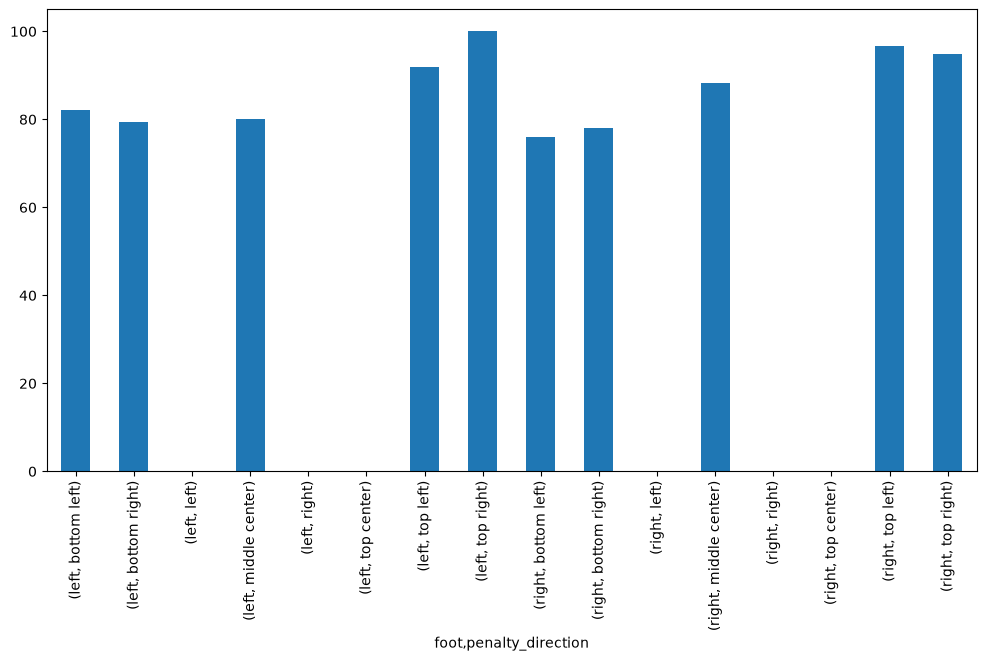

In [51]:
df_penalties.groupby([df_penalties["foot"], df_penalties["penalty_direction"]])["goal"].mean().mul(100).plot(kind="bar", figsize=(12, 6))